In [1]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib
from matplotlib import animation

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')
from python.polygon_based_correction import *
from python.animation import *
from eval.eval import *
from python.dataset_conversion import *
from python.misprediction_classifier import *
from autoencoder.src.data_loader import *

sleap.versions()
sleap.system_summary()

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit, ParameterGrid, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, make_scorer, recall_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


# Load data

In [2]:
predicted_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_with_scores.slp'
predicted_dataset = sleap.load_file(predicted_dataset_path)
print(predicted_dataset)

corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores_corrected.slp'
corrected_dataset = sleap.load_file(corrected_dataset_path)
print(corrected_dataset)

pred_pts_with_scores = get_all_untracked_points(predicted_dataset, 
                                                interpolate=False, use_labeled_only=False, load_pred_score=True)
gt_pts = get_all_untracked_points(corrected_dataset, interpolate=False, use_labeled_only=True)

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 3)


3000it [00:03, 969.11it/s] 


Missing point count: 0
reorder_idx.shape: (17,)
all_untracked_points shape: (3000, 17, 2)


3000it [00:03, 950.96it/s]

Missing point count: 0
reorder_idx.shape: (17,)


In [3]:
vid_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/animal_1_1h_20s.mp4'
vid = video_loader(vid_path)
print(vid.shape, vid.min(), vid.max())

(3000, 170, 174) 0.00784313725490196 1.0


In [4]:
missing_count = get_missing_count(pred_pts_with_scores)
print(f'total missing count in predicted points: {missing_count.sum()}')

missing_count = get_missing_count(gt_pts)
print(f'total missing count in ground truth points: {missing_count.sum()}')


total missing count in predicted points: 945.0
total missing count in ground truth points: 0.0


# Label assignment

In [5]:
def get_labels(pred_pts, gt_pts, dist_thres=3):
    pred_pts = pred_pts[:, :, :2]
    assert pred_pts.shape == gt_pts.shape, f'shape mismatch: {pred_pts.shape} != {gt_pts.shape}'
    frame_cnt, pt_cnt = pred_pts.shape[:2]
    labels = np.zeros((frame_cnt, pt_cnt))
    
    for frame_idx in range(frame_cnt):
        gt_curr_frame_pts = gt_pts[frame_idx]
        dist_queue = [] # (dist, pt_idx, nn_idx)
        used_nn = []
        
        for pt_idx in range(pt_cnt):
            curr_pt = pred_pts[frame_idx, pt_idx]
            dists = np.linalg.norm(gt_curr_frame_pts - curr_pt, axis=1)
            min_dist_idx = np.argmin(dists)
            dist_queue.append((dists[min_dist_idx], pt_idx, min_dist_idx))
            
        dist_queue.sort(key=lambda x: x[0])
        
        for dist, pt_idx, nn_idx in dist_queue:
            if dist > dist_thres:
                break
            if nn_idx not in used_nn:
                used_nn.append(nn_idx)
                labels[frame_idx, pt_idx] = 1
                
    print(f'total point count = {pt_cnt * frame_cnt}, correct = {int(labels.sum())}, incorrect = {(labels == 0).sum()}')
                
    return labels

In [6]:
pred_labels = get_labels(pred_pts_with_scores, gt_pts, dist_thres=5)

total point count = 51000, correct = 49577, incorrect = 1423


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/labels_check_20s.mp4
Animation saved to /home/mingxiao/Desktop/animation/labels_check_20s.mp4


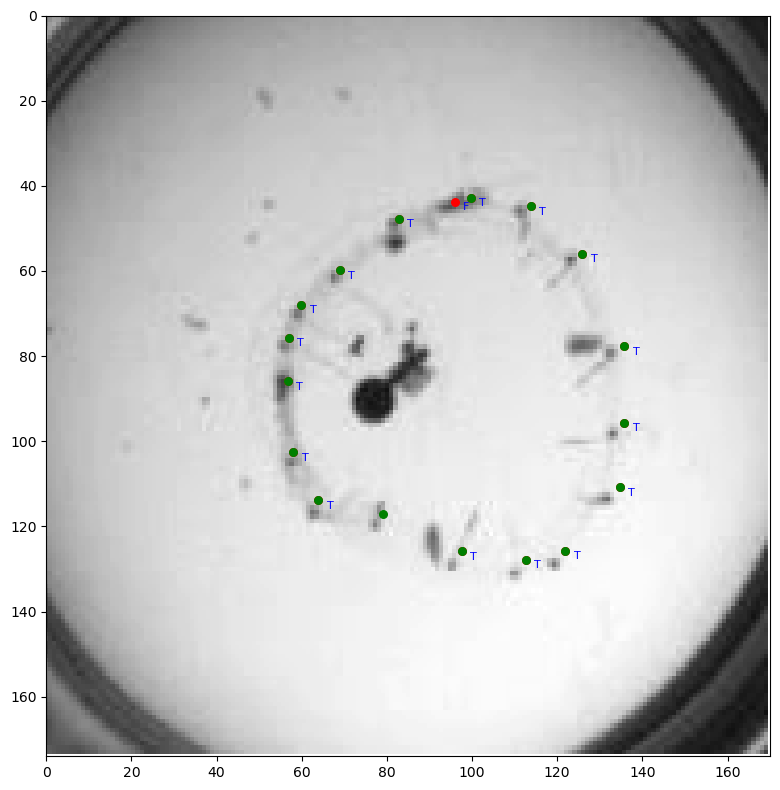

In [43]:
labels_check_20s_path = '/home/mingxiao/Desktop/animation/labels_check_20s.mp4'
text_dict = {0: 'F', 1: 'T'}
animate_classification_results(pred_pts_with_scores, gt_pts, pred_labels, 
                               bg_video=vid, bg_video_start_idx=0, 
                               text_dict=text_dict, output_path=labels_check_20s_path);

# Get training dataset

In [7]:
X_train, X_test, y_train, y_test, X, y, scaler = load_20s_dataset(dist_thres=5)

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 3)


3000it [00:03, 978.67it/s] 


Missing point count: 0
reorder_idx.shape: (17,)
all_untracked_points shape: (3000, 17, 2)


3000it [00:03, 959.65it/s] 


Missing point count: 0
reorder_idx.shape: (17,)
total point count = 50983, correct = 49560, incorrect = 1423
(50038, 4) (50038,)


# Train classifiers

## SVM

### default 

In [8]:
svm_clf = SVC(kernel='rbf')  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.990607513988809
              precision    recall  f1-score   support

         0.0       0.56      0.10      0.18        48
         1.0       0.99      1.00      1.00      4956

    accuracy                           0.99      5004
   macro avg       0.77      0.55      0.59      5004
weighted avg       0.99      0.99      0.99      5004



### imbalanced class weights

In [10]:
class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9852118305355716
              precision    recall  f1-score   support

         0.0       0.32      0.50      0.39        48
         1.0       1.00      0.99      0.99      4956

    accuracy                           0.99      5004
   macro avg       0.66      0.74      0.69      5004
weighted avg       0.99      0.99      0.99      5004



In [9]:
class_weights = {0: 10, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9842126298960832
              precision    recall  f1-score   support

         0.0       0.32      0.56      0.41        48
         1.0       1.00      0.99      0.99      4956

    accuracy                           0.98      5004
   macro avg       0.66      0.78      0.70      5004
weighted avg       0.99      0.98      0.99      5004



In [11]:
class_weights = {0: 100, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8924860111910472
              precision    recall  f1-score   support

         0.0       0.07      0.88      0.14        48
         1.0       1.00      0.89      0.94      4956

    accuracy                           0.89      5004
   macro avg       0.54      0.88      0.54      5004
weighted avg       0.99      0.89      0.93      5004



### resampling

In [12]:
def custom_resample(X, y, minority_class=0, minor_to_major_ratio=0.5, dowmsample_majority_ratio=1):
    """
    Resample dataset by undersampling majority class and oversampling minority class
    
    Args:
        X: features array
        y: labels array
        minority_class: the class to oversample (default 0)
        minor_to_major_ratio: desired ratio of minority to majority samples (default 0.5)
        dowmsample_majority_ratio: ratio of majority to minority samples to downsample (default 1; no downsampling)
    """
    # Separate majority and minority classes
    X_majority = X[y != minority_class]
    y_majority = y[y != minority_class]
    X_minority = X[y == minority_class]
    y_minority = y[y == minority_class]
    
    # Calculate desired number of samples
    n_minority = len(X_minority)
    n_majority = len(X_majority)
    desired_minority = int(n_majority * minor_to_major_ratio * dowmsample_majority_ratio)
    
    # Downsample majority class
    if dowmsample_majority_ratio < 1:
        indices = np.random.choice(len(X_majority), int(n_majority * dowmsample_majority_ratio), replace=False)
        X_majority_resampled = X_majority[indices]
        y_majority_resampled = y_majority[indices]
    else:
        X_majority_resampled = X_majority
        y_majority_resampled = y_majority
    
    # Oversample minority class
    if desired_minority > n_minority:
        indices = np.random.choice(len(X_minority), desired_minority, replace=True)
        X_minority_resampled = X_minority[indices]
        y_minority_resampled = y_minority[indices]
    else:
        X_minority_resampled = X_minority
        y_minority_resampled = y_minority
    
    print(f'majority count: {len(X_majority_resampled)}, minority count: {len(X_minority_resampled)}')
    
    # Combine the datasets
    X_resampled = np.vstack([X_majority_resampled, X_minority_resampled])
    y_resampled = np.hstack([y_majority_resampled, y_minority_resampled])
    
    # Shuffle
    indices = np.arange(len(X_resampled))
    np.random.shuffle(indices)
    
    return X_resampled[indices], y_resampled[indices]

In [ ]:
# TODO: add data augmentation (rotation/noise/use interpolation to make false positives)

#### upsample minority only

In [13]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.5)  # Aim for minority class to be half size of majority

class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 44604, minority count: 22302
Accuracy: 0.7835731414868106
              precision    recall  f1-score   support

         0.0       0.04      0.96      0.08        48
         1.0       1.00      0.78      0.88      4956

    accuracy                           0.78      5004
   macro avg       0.52      0.87      0.48      5004
weighted avg       0.99      0.78      0.87      5004



In [14]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.2)  # Aim for minority class to be half size of majority

class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 44604, minority count: 8920
Accuracy: 0.8701039168665068
              precision    recall  f1-score   support

         0.0       0.06      0.88      0.11        48
         1.0       1.00      0.87      0.93      4956

    accuracy                           0.87      5004
   macro avg       0.53      0.87      0.52      5004
weighted avg       0.99      0.87      0.92      5004



#### upsample minority & dowmsample majority

In [16]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.2,  # Aim for minority class to be half size of majority
    dowmsample_majority_ratio=0.8)

class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 35683, minority count: 7136
Accuracy: 0.8723021582733813
              precision    recall  f1-score   support

         0.0       0.06      0.88      0.12        48
         1.0       1.00      0.87      0.93      4956

    accuracy                           0.87      5004
   macro avg       0.53      0.87      0.52      5004
weighted avg       0.99      0.87      0.92      5004



In [17]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.2,  # Aim for minority class to be half size of majority
    dowmsample_majority_ratio=0.6)

class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 26762, minority count: 5352
Accuracy: 0.8647082334132694
              precision    recall  f1-score   support

         0.0       0.06      0.90      0.11        48
         1.0       1.00      0.86      0.93      4956

    accuracy                           0.86      5004
   macro avg       0.53      0.88      0.52      5004
weighted avg       0.99      0.86      0.92      5004



In [19]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.2,  # Aim for minority class to be half size of majority
    dowmsample_majority_ratio=0.6)

class_weights = {0: 8, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 26762, minority count: 5352
Accuracy: 0.8309352517985612
              precision    recall  f1-score   support

         0.0       0.05      0.94      0.10        48
         1.0       1.00      0.83      0.91      4956

    accuracy                           0.83      5004
   macro avg       0.52      0.88      0.50      5004
weighted avg       0.99      0.83      0.90      5004



### grid search + optimize for recall of class 0 + resampling

In [9]:
def grid_search_with_resampling(X, y, model, param_grid, 
                                n_splits=5, 
                                minority_class=0, 
                                minor_to_major_ratio=0.5,
                                dowmsample_majority_ratio=1):
    """
    Perform grid search with resampling in each fold
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    best_score = 0
    best_params = None
    best_model = None
    
    # Create scorer that focuses on minority class recall
    scorer = make_scorer(recall_score, pos_label=minority_class)
    
    # For each parameter combination
    for params in ParameterGrid(param_grid):
        fold_scores = []
        
        # For each fold
        for train_idx, val_idx in cv.split(X, y):
            # Split data
            X_train_fold = X[train_idx]
            y_train_fold = y[train_idx]
            X_val_fold = X[val_idx]
            y_val_fold = y[val_idx]
            
            # Resample training data
            X_train_resampled, y_train_resampled = custom_resample(
                X_train_fold, y_train_fold,
                minority_class=minority_class, 
                minor_to_major_ratio=minor_to_major_ratio,
                dowmsample_majority_ratio=dowmsample_majority_ratio
            )
            
            # Train model with current parameters
            model_fold = clone(model)
            model_fold.set_params(**params)
            model_fold.fit(X_train_resampled, y_train_resampled)
            
            # Score on validation set
            score = scorer(model_fold, X_val_fold, y_val_fold)
            fold_scores.append(score)
        
        # Average score across folds
        mean_score = np.mean(fold_scores)
        
        # Update best if improved
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            best_model = model_fold
            
        print(f"Params: {params}")
        print(f"Mean score: {mean_score:.3f}")
    
    return best_params, best_score, best_model

In [ ]:
C_range = np.logspace(-2, 2, 5)
gamma_range = np.logspace(-2, 2, 5)
param_grid = dict(gamma=gamma_range, C=C_range)

best_params, best_score, best_model = grid_search_with_resampling(
    X, y,
    model=SVC(kernel='rbf'),
    param_grid=param_grid
)

print(f"\nBest parameters: {best_params}")
print(f"Best score: {best_score:.3f}")

majority count: 39658, minority count: 19829
majority count: 39658, minority count: 19829


In [3]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, 
    minority_class=0, minor_to_major_ratio=0.5, dowmsample_majority_ratio=0.8)

majority count: 44620, minority count: 22310


In [4]:
recall_0_scorer = make_scorer(recall_score, pos_label=0)

In [ ]:
# C_range = np.logspace(0, 4, 5)
# gamma_range = np.logspace(0, 4, 5)
kernel_type = ['linear', 'rbf', 'sigmoid']
param_grid = dict(kernel=kernel_type)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv, scoring=recall_0_scorer, verbose=1)
grid.fit(X_train_resampled, y_train_resampled)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_)
)

# Predict on test set
y_pred = grid.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 3 candidates, totalling 15 fits
